# 01 · EDA y Modelado
## Sistema actuarial de prediccion de riesgo y costo esperado en seguros de automovil

**Proyecto Integrador · Actuaria y Ciencia de Datos · Machine Learning + Streamlit**

Este notebook documenta el flujo completo: exploracion de datos (EDA),
preprocesamiento con `Pipeline`/`ColumnTransformer`, entrenamiento y evaluacion
de modelos de regresion y clasificacion, reduccion de dimensionalidad (PCA) e
interpretacion de resultados.

> El mismo preprocesamiento se reutiliza en la app de Streamlit a traves del
> modulo `utils/preprocessing.py`, evitando duplicar codigo y fugas de informacion.

## 1. Comprension del problema
- **Regresion:** estimar `costo_esperado_anual_mxn` (costo anual de siniestros).
- **Clasificacion:** predecir `riesgo_alto` (1 = riesgo alto, ~15% de la cartera, desbalanceado).
- Relevancia actuarial: apoyar la **tarificacion** y la **segmentacion de riesgo** de la cartera.

In [49]:
import sys, os
sys.path.append(os.path.abspath(".."))  # para importar utils desde notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

from utils import preprocessing as pp

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Exploracion de datos (EDA)

In [50]:
df = pp.cargar_datos("../data/seguro_auto_actuarial.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1500, 31)


,poliza_id,edad_conductor,sexo,estado_civil,nivel_estudios,ocupacion,zona_residencia,region,antiguedad_cliente_anios,ingreso_mensual_mxn,...,canal_venta,tiene_gps,asistencia_vial,mantenimiento_al_dia,dias_hasta_renovacion,puntaje_riesgo_zona,numero_siniestros_12m,costo_esperado_anual_mxn,riesgo_alto,clase_costo
0,POL-00001,46,Femenino,Soltero,Posgrado,Independiente,Urbana,Sur,9.4,7038.0,...,Agente,Si,Si,Si,170,74.7,0,3321,0,Bajo
1,POL-00002,38,Masculino,Casado,Licenciatura,Estudiante,Suburbana,Centro,0.9,19655.0,...,Agente,No,No,Si,100,57.4,0,7196,0,Medio
2,POL-00003,48,Masculino,Divorciado,Licenciatura,Empleado,Urbana,Centro,0.1,16140.0,...,Agente,No,No,Si,69,71.3,0,2046,0,Bajo
3,POL-00004,60,Femenino,Divorciado,Licenciatura,Empleado,Urbana,Sur,0.1,14954.0,...,Online,Si,No,No,173,83.4,0,1379,0,Bajo
4,POL-00005,37,Femenino,Soltero,Preparatoria,Empleado,Urbana,Centro,3.9,27192.0,...,Agente,Si,Si,No,188,73.6,1,11787,1,Alto


In [51]:
# Tipos de variables y valores faltantes
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "faltantes": df.isna().sum(),
    "%faltantes": (100*df.isna().mean()).round(1),
    "unicos": df.nunique(),
})
resumen

,tipo,faltantes,%faltantes,unicos
poliza_id,str,0,0.0,1500
edad_conductor,int64,0,0.0,58
sexo,str,0,0.0,3
estado_civil,str,0,0.0,4
nivel_estudios,str,0,0.0,4
ocupacion,str,81,5.4,6
zona_residencia,str,0,0.0,3
region,str,0,0.0,5
antiguedad_cliente_anios,float64,0,0.0,166
ingreso_mensual_mxn,float64,106,7.1,1358


riesgo_alto
0    0.85
1    0.15
Name: proportion, dtype: float64


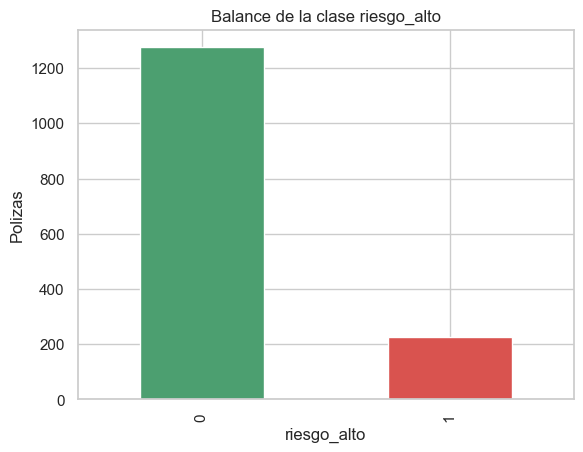

In [52]:
# Balance de la clase objetivo (desbalance ~15%)
print(df["riesgo_alto"].value_counts(normalize=True).round(3))
df["riesgo_alto"].value_counts().plot(kind="bar", color=["#4c9f70", "#d9534f"])
plt.title("Balance de la clase riesgo_alto"); plt.ylabel("Polizas"); plt.show()

In [53]:
# Estadisticos de variables numericas
df[pp.NUMERIC_COLS_BASE].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
edad_conductor,1500.0,40.8,12.5,18.0,32.0,41.0,49.0,75.0
antiguedad_cliente_anios,1500.0,4.2,4.2,0.0,1.2,2.8,5.8,25.0
ingreso_mensual_mxn,1394.0,25895.4,19108.1,6000.0,15058.0,21511.5,31394.0,331506.0
score_crediticio,1415.0,651.3,74.5,401.0,602.0,651.0,700.0,850.0
prima_mensual_mxn,1500.0,637.2,412.2,350.0,350.0,479.0,723.2,3348.0
suma_asegurada_mxn,1500.0,332304.1,188926.7,109519.0,198807.2,279564.0,398534.8,1600000.0
deducible_pct,1500.0,6.9,3.5,3.0,5.0,5.0,10.0,15.0
historial_siniestros_3_anios,1500.0,0.5,0.7,0.0,0.0,0.0,1.0,5.0
km_anuales,1500.0,15598.7,5527.0,2500.0,11866.5,15601.0,19293.8,40135.0
edad_vehiculo_anios,1500.0,6.1,3.5,0.4,3.5,5.4,8.0,21.4


Asimetria (skew): 7.36
min / mediana / max: 500 5570.5 131385
Percentil 99: 26505.0 | polizas con costo>30000: 10


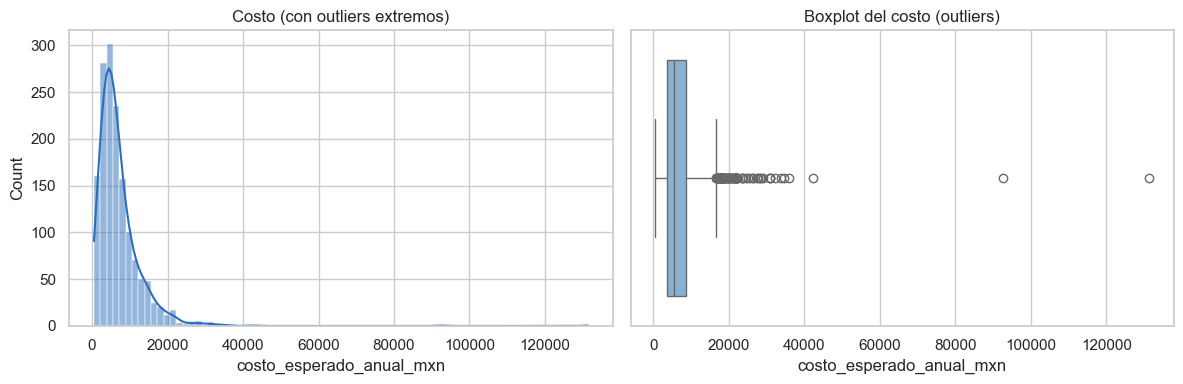

In [54]:
# El objetivo de regresion esta MUY sesgado por costos catastroficos
y_full = df["costo_esperado_anual_mxn"]
print("Asimetria (skew):", round(y_full.skew(), 2))
print("min / mediana / max:", y_full.min(), y_full.median(), y_full.max())
print("Percentil 99:", round(y_full.quantile(0.99), 0), "| polizas con costo>30000:", (y_full>30000).sum())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_full, kde=True, ax=ax[0], color="#2c6fbb"); ax[0].set_title("Costo (con outliers extremos)")
sns.boxplot(x=y_full, ax=ax[1], color="#7bb3e0"); ax[1].set_title("Boxplot del costo (outliers)")
plt.tight_layout(); plt.show()

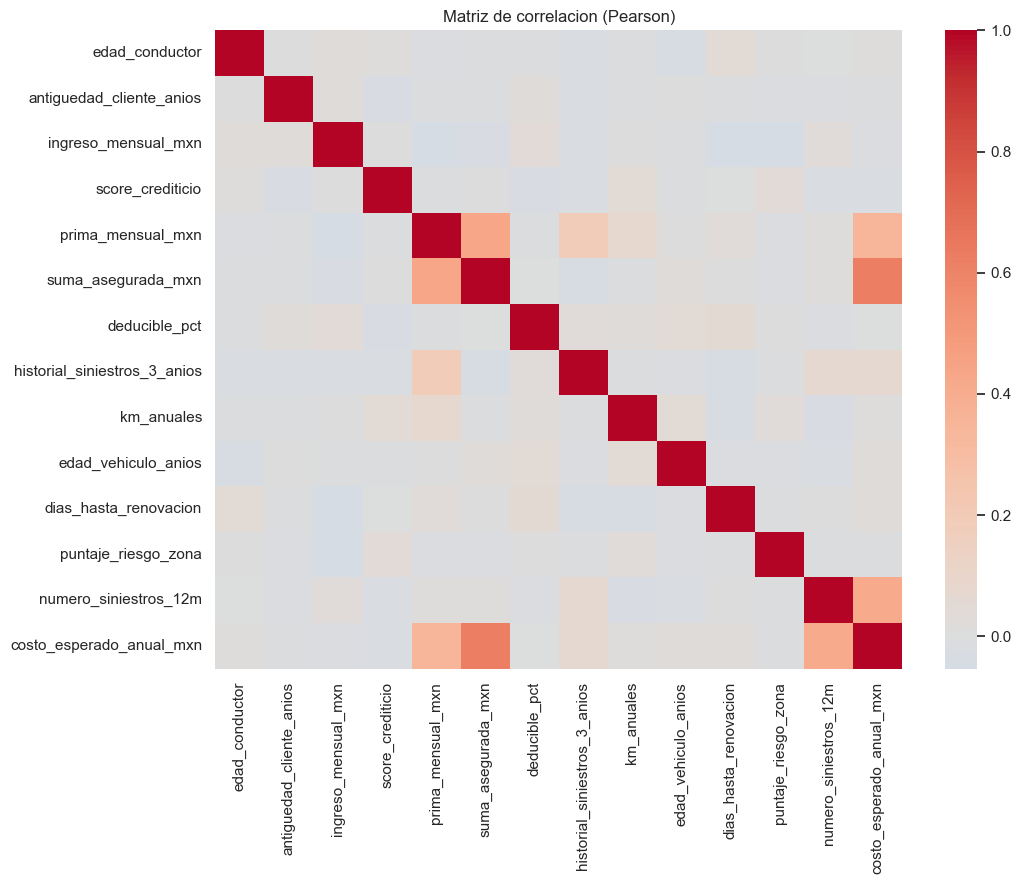

In [55]:
# Matriz de correlacion
plt.figure(figsize=(11, 9))
sns.heatmap(df[pp.NUMERIC_COLS_BASE + ["costo_esperado_anual_mxn"]].corr(),
            cmap="coolwarm", center=0)
plt.title("Matriz de correlacion (Pearson)"); plt.tight_layout(); plt.show()

**Interpretacion EDA:** hay faltantes en varias columnas; `ingreso_mensual_mxn` y `prima_mensual_mxn` tienen outliers; la clase `riesgo_alto` esta desbalanceada (~15%); y el **objetivo de regresion** presenta una cola extrema (asimetria > 7) por unos pocos **siniestros catastroficos** que conviene acotar.

## 3. Preprocesamiento
Ingenieria de variables + `ColumnTransformer` (imputacion, escalamiento y codificacion). Se ajusta **solo con el train** para evitar fugas de informacion. Ademas se **acota el costo al percentil 99** (tratamiento de outliers del objetivo).

In [56]:
df_feat = pp.preparar_features(df)
X = df_feat[pp.columnas_features()]
y_reg = pp.acotar_costo(df_feat[pp.TARGET_REG])   # costo acotado al p99
y_clf = df_feat[pp.TARGET_CLF]
print("Variables nuevas:", pp.NUMERIC_COLS_ENGINEERED, "+ grupo_edad")
print("Tope del costo (p99):", round(df_feat[pp.TARGET_REG].quantile(pp.TARGET_CAP_QUANTILE), 0))
df_feat[["edad_conductor","grupo_edad","km_por_anio_vehiculo","siniestros_x_suma","siniestros_x_prima"]].head()

Variables nuevas: ['km_por_anio_vehiculo', 'log_ingreso', 'ratio_prima_ingreso', 'siniestros_x_suma', 'siniestros_x_prima'] + grupo_edad
Tope del costo (p99): 26505.0


,edad_conductor,grupo_edad,km_por_anio_vehiculo,siniestros_x_suma,siniestros_x_prima
0,46,Adulto,1152.600000,0.0,0.0
1,38,Adulto_joven,3813.829787,0.0,0.0
2,48,Adulto,3140.789474,0.0,0.0
3,60,Mayor,1662.000000,0.0,0.0
4,37,Adulto_joven,2101.029412,298860.0,571.0


In [57]:
prep = pp.construir_preprocesador()
Xt = prep.fit_transform(X, y_clf)
print("Columnas originales:", len(pp.columnas_features()), "-> tras codificar:", Xt.shape[1])

Columnas originales: 33 -> tras codificar: 60


## 4. Modelado — Regresion (costo esperado)
Comparamos el desempeño **sin acotar** vs **acotando** el objetivo para mostrar el impacto de los outliers en el R².

In [58]:
# Impacto de acotar el objetivo: mismo modelo, target crudo vs acotado
y_crudo = df_feat[pp.TARGET_REG]
for etiqueta, y in [("Costo CRUDO (con outliers)", y_crudo), ("Costo ACOTADO p99", y_reg)]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("m", LinearRegression())])
    pipe.fit(Xtr, ytr); p = pipe.predict(Xte)
    print(f"{etiqueta:28s} R2={r2_score(yte,p):.3f}  RMSE={np.sqrt(mean_squared_error(yte,p)):.0f}")

Costo CRUDO (con outliers)   R2=0.413  RMSE=6933
Costo ACOTADO p99            R2=0.753  RMSE=2626


In [59]:
Xtr, Xte, ytr, yte = train_test_split(X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

modelos_reg = {
    "Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=10.0, max_iter=10000),
    "Arbol": DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                          max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE),
}
filas, pipes_reg = [], {}
for nombre, m in modelos_reg.items():
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("model", m)])
    pipe.fit(Xtr, ytr); pred = pipe.predict(Xte)
    filas.append({"Modelo": nombre,
                  "MAE": mean_absolute_error(yte, pred),
                  "RMSE": np.sqrt(mean_squared_error(yte, pred)),
                  "R2": r2_score(yte, pred)})
    pipes_reg[nombre] = pipe
pd.DataFrame(filas).set_index("Modelo").round(3)

,MAE,RMSE,R2
Modelo,,,
Lineal,1656.494,2625.696,0.753
Ridge,1655.481,2626.097,0.753
Lasso,1629.764,2603.421,0.757
Arbol,1900.111,2959.037,0.686
RandomForest,1764.774,2726.835,0.733


In [60]:
# Interpretacion: coeficientes del modelo lineal (>=5 variables relevantes)
lin = pipes_reg["Lineal"]
nombres = pp.nombres_features_transformadas(lin.named_steps["prep"])
coefs = lin.named_steps["model"].coef_
serie = pd.Series(coefs, index=nombres).sort_values(key=np.abs, ascending=False)
serie.head(10)

suma_asegurada_mxn              2910.154769
numero_siniestros_12m           2157.336825
tipo_vehiculo_Deportivo          672.494534
historial_siniestros_3_anios     496.220300
km_por_anio_vehiculo             413.480769
tipo_vehiculo_Compacto          -398.194789
tipo_vehiculo_Sedan             -387.123972
asistencia_vial                 -350.633577
segmento_marca                   345.149246
estado_civil_Viudo              -310.454081
dtype: float64

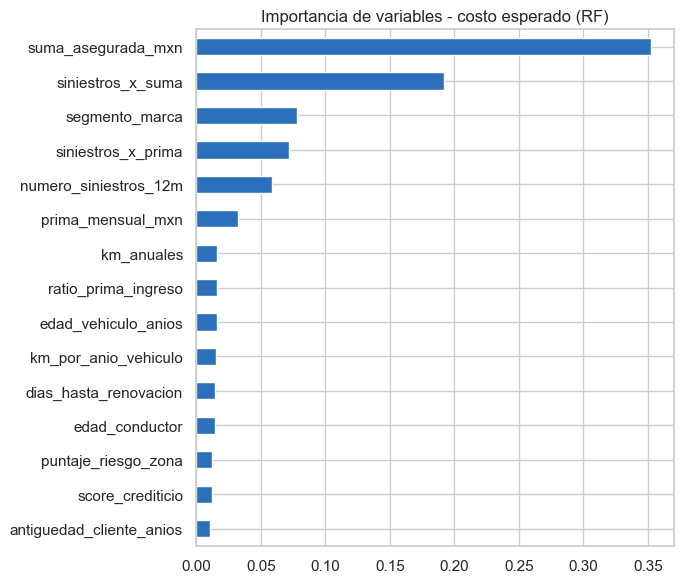

In [61]:
# Importancia de variables (Random Forest regresion)
rf = pipes_reg["RandomForest"]
imp = pd.Series(rf.named_steps["model"].feature_importances_,
                index=pp.nombres_features_transformadas(rf.named_steps["prep"]))
imp.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(7,6), color="#2c6fbb")
plt.title("Importancia de variables - costo esperado (RF)"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Modelado — Clasificacion (riesgo alto)
Se usa `class_weight="balanced"` por el desbalance. No basta con accuracy: reportamos precision, recall y F1.

In [62]:
Xtr, Xte, ytr, yte = train_test_split(X, y_clf, test_size=0.2,
                                      random_state=RANDOM_STATE, stratify=y_clf)
modelos_clf = {
    "Logistica": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Arbol": DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                    class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                           class_weight="balanced", n_jobs=-1,
                                           random_state=RANDOM_STATE),
}
filas, pipes_clf = [], {}
for nombre, m in modelos_clf.items():
    pipe = Pipeline([("prep", pp.construir_preprocesador()), ("model", m)])
    pipe.fit(Xtr, ytr); pred = pipe.predict(Xte)
    filas.append({"Modelo": nombre,
                  "Accuracy": accuracy_score(yte, pred),
                  "Precision": precision_score(yte, pred, zero_division=0),
                  "Recall": recall_score(yte, pred, zero_division=0),
                  "F1": f1_score(yte, pred, zero_division=0)})
    pipes_clf[nombre] = pipe
pd.DataFrame(filas).set_index("Modelo").round(3)

,Accuracy,Precision,Recall,F1
Modelo,,,,
Logistica,0.897,0.603,0.911,0.726
Arbol,0.907,0.649,0.822,0.725
RandomForest,0.913,0.679,0.800,0.735


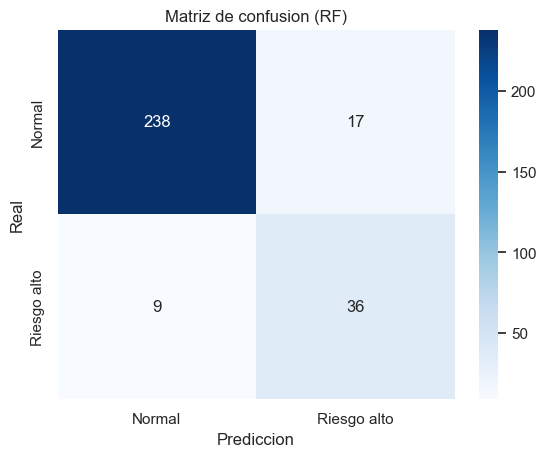

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       255
           1       0.68      0.80      0.73        45

    accuracy                           0.91       300
   macro avg       0.82      0.87      0.84       300
weighted avg       0.92      0.91      0.92       300



In [63]:
# Matriz de confusion del Random Forest
rf = pipes_clf["RandomForest"]; pred = rf.predict(Xte)
cm = confusion_matrix(yte, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Riesgo alto"], yticklabels=["Normal","Riesgo alto"])
plt.title("Matriz de confusion (RF)"); plt.xlabel("Prediccion"); plt.ylabel("Real"); plt.show()
print(classification_report(yte, pred))

## 6. Reduccion de dimensionalidad (PCA)

Varianza explicada: [0.108 0.093] | acumulada: 0.201


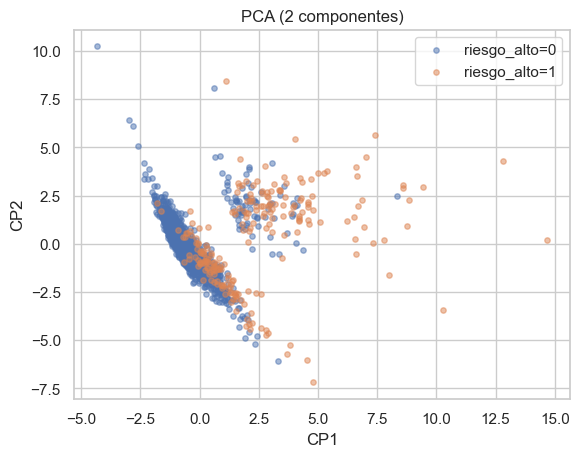

In [64]:
prep = pp.construir_preprocesador()
Xt = prep.fit_transform(X, y_clf)
if hasattr(Xt, "toarray"): Xt = Xt.toarray()
pca = PCA(n_components=2, random_state=RANDOM_STATE)
comp = pca.fit_transform(Xt)
print("Varianza explicada:", pca.explained_variance_ratio_.round(3),
      "| acumulada:", pca.explained_variance_ratio_.sum().round(3))
for v in [0,1]:
    mask = y_clf.values==v
    plt.scatter(comp[mask,0], comp[mask,1], s=15, alpha=0.5, label=f"riesgo_alto={v}")
plt.legend(); plt.title("PCA (2 componentes)"); plt.xlabel("CP1"); plt.ylabel("CP2"); plt.show()

## 7. Conclusiones
- El R² del costo estaba limitado por ~10 **siniestros catastroficos**; al acotarlos
  al percentil 99 y añadir interacciones (`siniestros_x_suma`, `siniestros_x_prima`)
  el **R² pasa de ~0.42 a ~0.75**.
- Los modelos lineales y de **Random Forest** quedan muy parejos; los lineales aportan
  interpretabilidad y los de arboles capturan no linealidades.
- En clasificacion, el balanceo de clases mejora el **recall** de la clase de
  riesgo alto, clave para el negocio asegurador.
- **Etica:** la base es sintetica; variables sensibles (`sexo`, `region`,
  `ocupacion`) pueden inducir sesgos y requieren validacion y auditoria antes de
  cualquier uso real.